# Best Strategies -- Equity Curves

General-purpose sandbox for pulling equity curves / figures out of the grid-search results for
slides or write-ups. Reads the winning configuration for each cost scenario directly from
`results/grid_search/cross_scenario_best.csv` (doesn't hardcode numbers), re-runs each one
through `simulate_ensemble()`, and overlays the equity curves.

Default selection below is **none / base / high** -- `low` is skipped because it shares the same
winning configuration as `none` and `base` (10% OTM, 30 day contract, roll at 3 days), so it adds
a 4th line without adding a 4th distinct strategy. Change `SCENARIOS_TO_PLOT` to compare a
different set.

In [1]:
%load_ext autoreload
%autoreload 2
# autoreload re-imports cba_backtest.py/grid_search.py automatically whenever they change on
# disk, so editing the production scripts doesn't require restarting this kernel each time.

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]  # scripts/utils/ -> project root
sys.path.insert(0, str(ROOT / "scripts" / "eda"))
sys.path.insert(0, str(ROOT / "scripts" / "backtest"))

from metrics import summarize
from cba_backtest import simulate_ensemble
from grid_search import load_data

# cba_backtest.py / grid_search.py both call matplotlib.use("Agg") at import time (so the
# standalone scripts can save PNGs headless) -- that overrides any backend set before this
# point, so re-assert inline plotting *after* importing them, not before.
%matplotlib inline

In [2]:
SCENARIOS_TO_PLOT = ["none", "base", "high"]

# Per-scenario cost assumptions -- keep these in sync with grid_search.py's COST_SCENARIOS.
COST_SCENARIOS = {
    "none": {"tsla_cost_pct": 0.000, "tsll_cost_pct": 0.000, "borrow": False},
    "low":  {"tsla_cost_pct": 0.005, "tsll_cost_pct": 0.015, "borrow": True},
    "base": {"tsla_cost_pct": 0.010, "tsll_cost_pct": 0.030, "borrow": True},
    "high": {"tsla_cost_pct": 0.020, "tsll_cost_pct": 0.060, "borrow": True},
}
STOP_LOSS_PCT = 0.5
MAX_DTE = 200

best = pd.read_csv(ROOT / "results" / "grid_search" / "cross_scenario_best.csv")
best = best.set_index("scenario").loc[SCENARIOS_TO_PLOT]
best

,tsla_cost_pct,tsll_cost_pct,borrow_included,bucket,target_dte,roll_dte,CAGR,Max DD,Sharpe,stop_loss_rolls_total
scenario,,,,,,,,,,
none,0.00,0.00,False,10% OTM,30,3,0.378023,-0.199937,1.309420,5264
base,0.01,0.03,True,10% OTM,30,3,0.327211,-0.231290,1.127600,4833
high,0.02,0.06,True,10% OTM,90,5,0.332962,-0.205289,1.016479,4555


## Load data and run each winning configuration

In [3]:
data = load_data()
# load_data() returns (returns, tsla_calls, tsla_spot, tsla_lookup, tsla_vol_lookup, tsla_sigma,
#                       tsll_calls, tsll_spot, tsll_lookup, tsll_vol_lookup, tsll_sigma, borrow_df)
(returns, tsla_calls, tsla_spot, tsla_lookup, tsla_vol_lookup, tsla_sigma,
 tsll_calls, tsll_spot, tsll_lookup, tsll_vol_lookup, tsll_sigma, borrow_df) = data

curves = {}
stats_by_scenario = {}

for scenario in SCENARIOS_TO_PLOT:
    row = best.loc[scenario]
    costs = COST_SCENARIOS[scenario]
    tsll_borrow_rate = borrow_df["TSLL"] if costs["borrow"] else None

    equity, stats = simulate_ensemble(
        returns,
        tsla_calls, tsla_spot, tsla_lookup, tsla_vol_lookup, tsla_sigma,
        tsll_calls, tsll_spot, tsll_lookup, tsll_vol_lookup, tsll_sigma,
        row["bucket"], int(row["target_dte"]), int(row["roll_dte"]), MAX_DTE,
        stop_loss_pct=STOP_LOSS_PCT,
        tsla_cost_pct=costs["tsla_cost_pct"], tsll_cost_pct=costs["tsll_cost_pct"],
        tsll_borrow_rate=tsll_borrow_rate,
    )
    equity = equity / equity.iloc[0]
    label = f"{scenario.capitalize()} -- {row['bucket']}, {int(row['target_dte'])}d / roll@{int(row['roll_dte'])}d"
    curves[label] = equity
    stats_by_scenario[scenario] = stats

summary_df = pd.DataFrame([
    summarize(eq, eq.pct_change().dropna(), label) for label, eq in curves.items()
])
summary_df

,Strategy,CAGR,Ann. Vol,Sharpe,Max DD,Calmar
0,"None -- 10% OTM, 30d / roll@3d",0.378023,0.274758,1.309420,-0.199937,1.890713
1,"Base -- 10% OTM, 30d / roll@3d",0.327211,0.288988,1.127600,-0.231290,1.414718
2,"High -- 10% OTM, 90d / roll@5d",0.332962,0.339426,1.016479,-0.205289,1.621917


## Plot: equity curves + drawdown, overlaid

Saved -> observations/strategies/grid_search/best_strategies_equity_curves.png


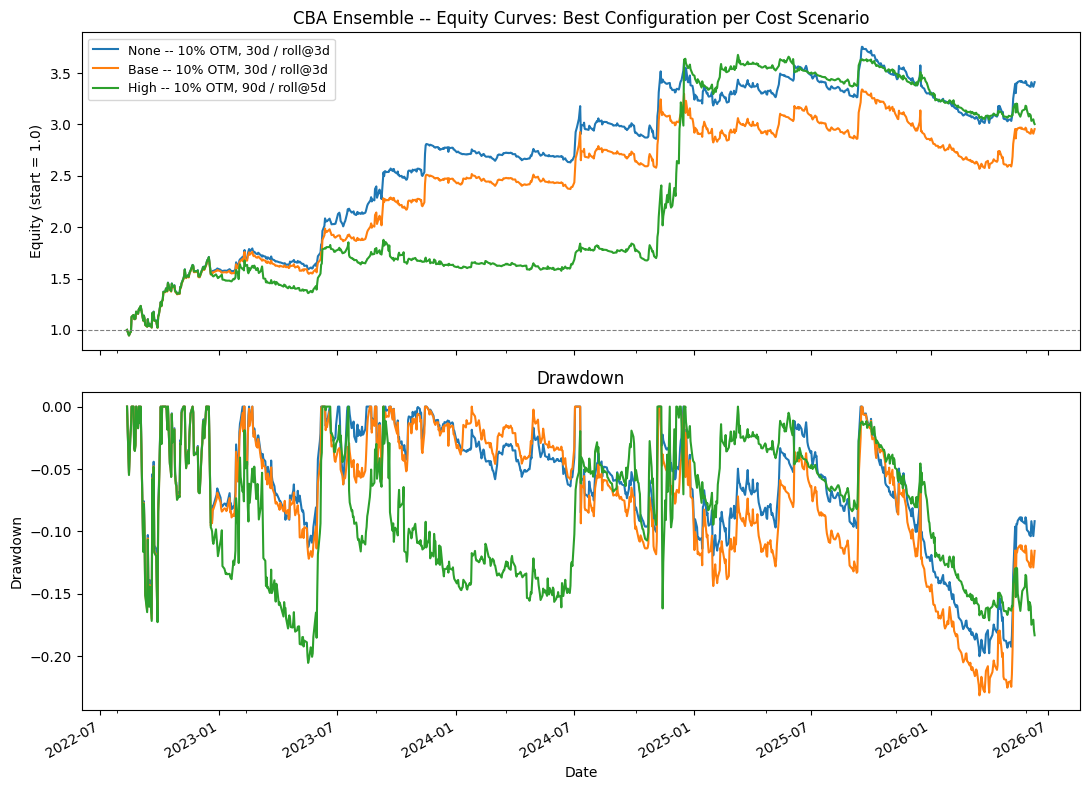

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

for label, eq in curves.items():
    eq.plot(ax=axes[0], label=label, linewidth=1.5)
axes[0].axhline(1.0, color="grey", linestyle="--", linewidth=0.8)
axes[0].set_title("CBA Ensemble -- Equity Curves: Best Configuration per Cost Scenario")
axes[0].set_ylabel("Equity (start = 1.0)")
axes[0].legend(fontsize=9, loc="upper left")

for label, eq in curves.items():
    dd = eq / eq.cummax() - 1
    dd.plot(ax=axes[1], label=label, linewidth=1.5)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")

fig.tight_layout()
fig.savefig(ROOT / "observations" / "strategies" / "grid_search" / "best_strategies_equity_curves.png",
            dpi=150, bbox_inches="tight")
print("Saved -> observations/strategies/grid_search/best_strategies_equity_curves.png")

## Reuse this for other results

To pull a different comparison (e.g. all 4 scenarios, or specific buckets), just change
`SCENARIOS_TO_PLOT` above and re-run from that cell down -- everything else (data loading,
simulation, plotting) is already wired up. For a parameter sweep instead of scenario
comparison, see `cba_ensemble_sandbox.ipynb` in this same folder.